In [41]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm
import pandas as pd

In [42]:
def estimate_dx_angle(img1, img2, fov_deg=54.2, match_count=100):
    img1_gray = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    img2_gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
    H, W = img1.shape[:2]

    orb = cv2.ORB_create(nfeatures=1000)
    kp1, des1 = orb.detectAndCompute(img1_gray, None)
    kp2, des2 = orb.detectAndCompute(img2_gray, None)

    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = sorted(bf.match(des1, des2), key=lambda x: x.distance)[:match_count]

    margin_x = W * 0.2
    margin_y = H * 0.1

    dx_list = []
    for m in matches:
        x1, y1 = kp1[m.queryIdx].pt
        x2, y2 = kp2[m.trainIdx].pt
        if (
            abs(x1 - W/2) > margin_x
            and margin_y < y1 < H - margin_y
            and margin_y < y2 < H - margin_y
        ):
            dx_list.append(x2 - x1)

    if not dx_list:
        return None

    mean_dx = np.mean(dx_list)
    fov_rad = np.radians(fov_deg)
    angle_rad = 2 * np.arctan((mean_dx * np.tan(fov_rad / 2)) / W)
    return np.degrees(angle_rad)


def process_folder_with_cleaning(folder_path, fov_deg=54.2, max_deviation=5.0):
    image_paths = sorted(glob(os.path.join(folder_path, "*.jpg")))
    n = len(image_paths)
    if n < 2:
        raise ValueError("Le dossier doit contenir au moins deux images")

    # 1) compute raw transitions
    raw_deltas = []
    for i in range(n - 1):
        img1 = cv2.imread(image_paths[i])
        img2 = cv2.imread(image_paths[i + 1])
        raw_deltas.append(estimate_dx_angle(img1, img2, fov_deg=fov_deg))

    # 2) median of valid (non-None) deltas
    valid = [d for d in raw_deltas if d is not None]
    median_delta = float(np.median(valid)) if valid else 0.0

    # 3) clean outliers
    cleaned = [
        d if (d is not None and abs(d - median_delta) <= max_deviation) else None
        for d in raw_deltas
    ]

    # 4) fill every missing slot — including the first image — with median
    #    now delta_filled has length n
    deltas_filled = [median_delta] + [
        d if d is not None else median_delta
        for d in cleaned
    ]

    # 5) leave azimut_estime for later (all None)
    azimuts = [None] * n

    # 6) build DataFrame
    df = pd.DataFrame({
        "image":          [os.path.basename(p) for p in image_paths],
        "azimut_estime":  azimuts,
        "delta_angle":    deltas_filled
    })
    print(df)

    return df



In [43]:
name = "nemours"
cam_id = "192_168_1_12"


# === Exécution
folder_path = f"/Users/mateo/pyronear/vision/smoke-localization/site_data/{name}/ref_images/{cam_id}"
df_cleaned = process_folder_with_cleaning(folder_path)

df_cleaned.to_csv(f"/Users/mateo/pyronear/vision/smoke-localization/site_data/{name}/df_ref_images_{cam_id}.csv")

          image azimut_estime  delta_angle
0   ref_000.jpg          None    -9.173355
1   ref_010.jpg          None    -8.239507
2   ref_020.jpg          None    -9.127318
3   ref_030.jpg          None    -9.173355
4   ref_040.jpg          None    -9.003198
5   ref_050.jpg          None    -9.071262
6   ref_060.jpg          None    -9.519058
7   ref_070.jpg          None    -9.136612
8   ref_080.jpg          None    -9.032664
9   ref_090.jpg          None    -8.989061
10  ref_100.jpg          None    -9.067161
11  ref_110.jpg          None    -9.011270
12  ref_120.jpg          None    -9.216214
13  ref_130.jpg          None    -8.746367
14  ref_140.jpg          None    -9.590894
15  ref_150.jpg          None    -9.652573
16  ref_160.jpg          None    -9.228713
17  ref_170.jpg          None    -9.769521
18  ref_180.jpg          None    -9.153384
19  ref_190.jpg          None    -9.557887
20  ref_200.jpg          None    -8.806077
21  ref_210.jpg          None    -9.306146
22  ref_220

In [44]:
# import glob
# imgs = glob.glob("/Users/mateo/pyronear/vision/smoke-localization/site_data/nemours/ref_images/**/*")
# len(imgs)
# import shutil
# for file in imgs:
#     folder, name = os.path.split(file)
#     azimuth = int(name.split('_')[1].split('.')[0])
#     new_name = os.path.join(folder, f"ref_{str(azimuth).zfill(3)}.jpg")
#     shutil.move(file, new_name)

Number of raw matches: 100
Number of filtered dx entries: 23
dx_list sample (first 10): [-425.0880584716797, -429.1199951171875, -426.39862060546875, -419.0400085449219, -410.0, -423.6000213623047, -423.3600311279297, -411.2640380859375, -424.80003356933594, -421.9200134277344]
Mean dx: -422.96 px -> angle: -9.67°
Median dx: -423.60 px -> angle: -9.68°


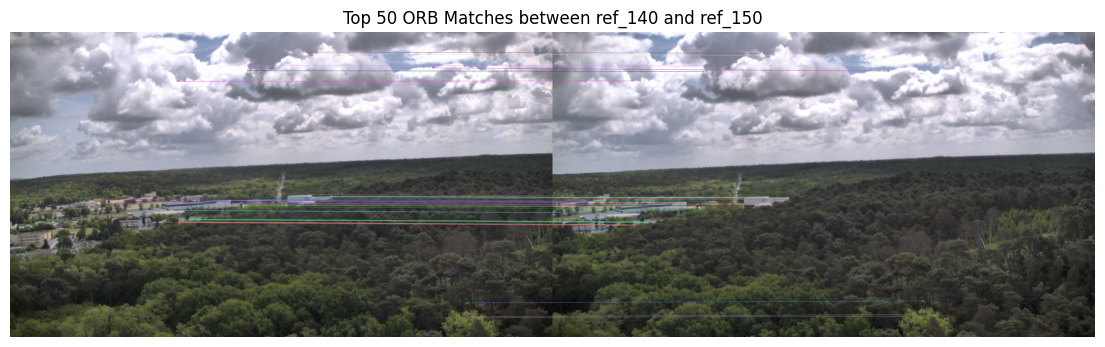

In [45]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Paths to your reference images
base_folder = "/Users/mateo/pyronear/vision/smoke-localization/site_data/nemours/ref_images/192_168_1_11"
img1_path = os.path.join(base_folder, "ref_140.jpg")
img2_path = os.path.join(base_folder, "ref_150.jpg")

# Load images
img1 = cv2.imread(img1_path)
img2 = cv2.imread(img2_path)
img1_gray = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
img2_gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# ORB feature detection
orb = cv2.ORB_create(nfeatures=1000)
kp1, des1 = orb.detectAndCompute(img1_gray, None)
kp2, des2 = orb.detectAndCompute(img2_gray, None)

# BFMatcher with cross-check
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)
matches = sorted(matches, key=lambda m: m.distance)[:100]

# Image dimensions
H, W = img1.shape[:2]
margin_x = W * 0.2
margin_y = H * 0.1

# Compute dx list
dx_list = [
    kp2[m.trainIdx].pt[0] - kp1[m.queryIdx].pt[0]
    for m in matches
    if (
        abs(kp1[m.queryIdx].pt[0] - W/2) > margin_x
        and margin_y < kp1[m.queryIdx].pt[1] < H - margin_y
        and margin_y < kp2[m.trainIdx].pt[1] < H - margin_y
    )
]

# Compute statistics
mean_dx = np.mean(dx_list) if dx_list else float('nan')
median_dx = np.median(dx_list) if dx_list else float('nan')
fov_deg = 54.2
angle_deg_from_mean = np.degrees(2 * np.arctan((mean_dx * np.tan(np.radians(fov_deg) / 2)) / W))
angle_deg_from_median = np.degrees(2 * np.arctan((median_dx * np.tan(np.radians(fov_deg) / 2)) / W))

print(f"Number of raw matches: {len(matches)}")
print(f"Number of filtered dx entries: {len(dx_list)}")
print(f"dx_list sample (first 10): {dx_list[:10]}")
print(f"Mean dx: {mean_dx:.2f} px -> angle: {angle_deg_from_mean:.2f}°")
print(f"Median dx: {median_dx:.2f} px -> angle: {angle_deg_from_median:.2f}°")

# Draw top 50 matches for visualization
matches_to_draw = matches[:50]
img_matches = cv2.drawMatches(
    img1, kp1, img2, kp2, matches_to_draw, None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(14, 7))
plt.title("Top 50 ORB Matches between ref_140 and ref_150")
plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


In [48]:
for m in matches:
    print(kp2[m.trainIdx].pt)

(383.0, 915.0)
(436.0, 901.0)
(165.8880157470703, 803.5200805664062)
(1111.44970703125, 792.1152954101562)
(1111.2000732421875, 786.0000610351562)
(1111.1041259765625, 784.5120849609375)
(433.0, 898.0)
(1651.0, 1341.0)
(1019.0, 778.0)
(409.5360412597656, 857.0880737304688)
(1033.2000732421875, 818.4000244140625)
(436.32000732421875, 897.1200561523438)
(694.0800170898438, 836.6400146484375)
(1111.6800537109375, 784.800048828125)
(112.32000732421875, 813.6000366210938)
(628.9920654296875, 806.97607421875)
(691.2000732421875, 829.4400634765625)
(408.499267578125, 856.3969116210938)
(1109.3760986328125, 783.8209228515625)
(375.3216552734375, 234.31683349609375)
(1032.653076171875, 818.657470703125)
(979.4030151367188, 104.50946807861328)
(383.40045166015625, 913.7113647460938)
(168.4095458984375, 806.2159423828125)
(388.0, 914.0)
(736.800048828125, 802.800048828125)
(382.8000183105469, 912.0000610351562)
(436.8000183105469, 901.2000122070312)
(384.0, 914.4000244140625)
(285.1200256347656, 

In [51]:
import os
import cv2
import numpy as np

# 1) load & gray
base = "/Users/mateo/pyronear/vision/smoke-localization/site_data/nemours/ref_images/192_168_1_11"
p1   = os.path.join(base, "ref_140.jpg")
p2   = os.path.join(base, "ref_150.jpg")
im1  = cv2.imread(p1); g1 = cv2.cvtColor(im1, cv2.COLOR_BGR2GRAY)
im2  = cv2.imread(p2); g2 = cv2.cvtColor(im2, cv2.COLOR_BGR2GRAY)

# 2) ORB + match
orb      = cv2.ORB_create(2000)
kp1, d1  = orb.detectAndCompute(g1, None)
kp2, d2  = orb.detectAndCompute(g2, None)
bf       = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches  = sorted(bf.match(d1, d2), key=lambda m: m.distance)[:500]
pts1     = np.float32([kp1[m.queryIdx].pt for m in matches])
pts2     = np.float32([kp2[m.trainIdx].pt for m in matches])

# 3) camera intrinsics (approx)
H_img, W_img = g1.shape
fov_h = np.radians(54.2)
fx = fy = (W_img/2) / np.tan(fov_h/2)
cx, cy = W_img/2, H_img/2
K = np.array([[fx, 0, cx],
              [0, fy, cy],
              [0,  0,  1]])

# 4) estimate homography
H_mat, mask = cv2.findHomography(pts1, pts2, cv2.RANSAC, 5.0)

# 5) extract rotation
R_est = np.linalg.inv(K) @ H_mat @ K
# enforce orthonormality
U, _, Vt = np.linalg.svd(R_est)
R = U @ Vt

# 6) yaw = arctan2(r[0,2], r[2,2])
yaw_rad = np.arctan2(R[0, 2], R[2, 2])
yaw_deg = np.degrees(yaw_rad)

print(f"Homography‐based yaw from ref_140→ref_150: {yaw_deg:.2f}°")


Homography‐based yaw from ref_140→ref_150: -6.55°


Procrustes‐based yaw from ref_140→ref_150: -8.92°


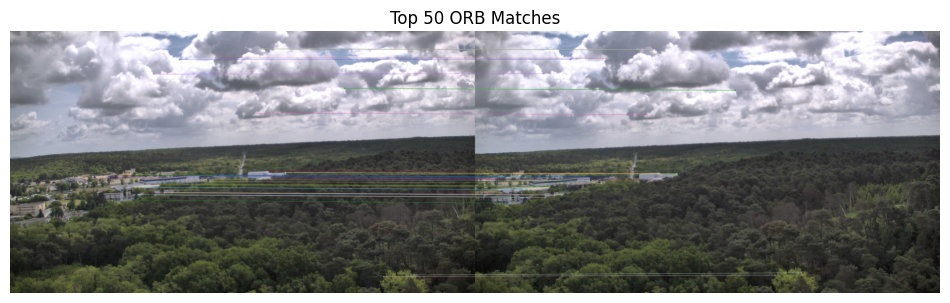

In [8]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ── Update this base path to match your local folder ─────────────────────
base_folder = "/Users/mateo/pyronear/vision/smoke-localization/site_data/nemours/ref_images/192_168_1_11"
img1_path   = os.path.join(base_folder, "ref_140.jpg")
img2_path   = os.path.join(base_folder, "ref_150.jpg")

# ── Load & convert ───────────────────────────────────────────────────────
img1 = cv2.imread(img1_path)
img2 = cv2.imread(img2_path)
g1   = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
g2   = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# ── ORB matching ─────────────────────────────────────────────────────────
orb       = cv2.ORB_create(2000)
kp1, des1 = orb.detectAndCompute(g1, None)
kp2, des2 = orb.detectAndCompute(g2, None)
bf        = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches   = sorted(bf.match(des1, des2), key=lambda m: m.distance)[:200]

pts1 = np.array([kp1[m.queryIdx].pt for m in matches], dtype=np.float32)
pts2 = np.array([kp2[m.trainIdx].pt  for m in matches], dtype=np.float32)

# ── Intrinsics & bearing vectors ────────────────────────────────────────
H_img, W_img = g1.shape
fov_deg      = 54.2
fov_rad      = np.radians(fov_deg)
fx = fy = (W_img/2) / np.tan(fov_rad/2)
cx, cy = W_img/2, H_img/2

# normalize to 3D bearing vectors
b1 = np.column_stack([(pts1[:,0] - cx)/fx,
                      (pts1[:,1] - cy)/fy,
                      np.ones(len(pts1))])
b2 = np.column_stack([(pts2[:,0] - cx)/fx,
                      (pts2[:,1] - cy)/fy,
                      np.ones(len(pts2))])

# ── Compute best‐fit rotation via SVD (Procrustes) ───────────────────────
M = b2.T @ b1
U, _, Vt = np.linalg.svd(M)
R = U @ Vt
if np.linalg.det(R) < 0:
    U[:,-1] *= -1
    R = U @ Vt

# ── Extract yaw from R ───────────────────────────────────────────────────
# For a pure yaw about Y, R[0,2]=sin(yaw), R[2,2]=cos(yaw)
yaw_rad = np.arctan2(R[0,2], R[2,2])
yaw_deg = np.degrees(yaw_rad)
print(f"Procrustes‐based yaw from ref_140→ref_150: {yaw_deg:.2f}°")

# ── Visualize top matches ────────────────────────────────────────────────
img_matches = cv2.drawMatches(
    img1, kp1, img2, kp2,
    matches[:50], None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)
plt.figure(figsize=(12,6))
plt.title("Top 50 ORB Matches")
plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


In [55]:
import os
import cv2
import numpy as np
import pandas as pd
from glob import glob
from tqdm import tqdm

def estimate_yaw_procrustes(img1, img2, fov_deg=54.2, match_count=200):
    """
    Compute the yaw (degrees) between img1→img2 by
    1) ORB matching
    2) converting matched points to 3D bearing vectors via intrinsics
    3) solving R = argmin ||R b1 - b2|| via SVD
    4) extracting yaw = atan2(R[0,2], R[2,2])
    """
    # grayscale
    g1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    g2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
    H, W = g1.shape

    # ORB detect+match
    orb   = cv2.ORB_create(nfeatures=2000)
    kp1, d1 = orb.detectAndCompute(g1, None)
    kp2, d2 = orb.detectAndCompute(g2, None)
    if d1 is None or d2 is None:
        return None

    bf     = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches= sorted(bf.match(d1, d2), key=lambda m: m.distance)[:match_count]
    if len(matches) < 6:
        return None

    # points arrays
    pts1 = np.array([kp1[m.queryIdx].pt for m in matches], dtype=np.float32)
    pts2 = np.array([kp2[m.trainIdx].pt  for m in matches], dtype=np.float32)

    # intrinsics approximate
    fov_rad = np.radians(fov_deg)
    fx = fy = (W/2) / np.tan(fov_rad/2)
    cx, cy = W/2, H/2

    # build bearing vectors
    b1 = np.column_stack([
        (pts1[:,0] - cx)/fx,
        (pts1[:,1] - cy)/fy,
        np.ones(len(pts1))
    ])
    b2 = np.column_stack([
        (pts2[:,0] - cx)/fx,
        (pts2[:,1] - cy)/fy,
        np.ones(len(pts2))
    ])

    # Procrustes: R = U Vt
    M = b2.T @ b1
    U, _, Vt = np.linalg.svd(M)
    R = U @ Vt
    if np.linalg.det(R) < 0:
        U[:,-1] *= -1
        R = U @ Vt

    # yaw = atan2(R[0,2], R[2,2])
    yaw = np.degrees(np.arctan2(R[0,2], R[2,2]))
    return yaw

def process_folder_with_cleaning(folder_path, fov_deg=54.2, max_deviation=5.0):
    """
    For every consecutive image pair in folder_path, estimate yaw with Procrustes,
    compute the median, null out outliers > max_deviation, fill missing with median,
    and return a DataFrame of image, delta_angle and azimut_estime=None.
    """
    image_paths = sorted(glob(os.path.join(folder_path, "*.jpg")))
    n = len(image_paths)
    if n < 2:
        raise ValueError("Need at least two images")

    # 1) compute raw yaw deltas
    raw = []
    for i in tqdm(range(n-1), desc="Estimating yaw deltas"):
        im1 = cv2.imread(image_paths[i])
        im2 = cv2.imread(image_paths[i+1])
        raw.append(estimate_yaw_procrustes(im1, im2, fov_deg=fov_deg))

    # 2) median of valid
    valid = [d for d in raw if d is not None]
    med = float(np.median(valid)) if valid else 0.0

    # 3) clean outliers
    cleaned = [
        d if (d is not None and abs(d - med) <= max_deviation) else None
        for d in raw
    ]

    # 4) fill every slot (including first) with median
    deltas = [med] + [ (d if d is not None else med) for d in cleaned ]

    # 5) azimut_estime left None for now
    az = [None] * n

    # 6) DataFrame
    df = pd.DataFrame({
        "image":          [os.path.basename(p) for p in image_paths],
        "azimut_estime":  az,
        "delta_angle":    deltas
    })

    return df


In [57]:
name = "nemours"
cam_id = "192_168_1_11"


# === Exécution
folder_path = f"/Users/mateo/pyronear/vision/smoke-localization/site_data/{name}/ref_images/{cam_id}"
df_cleaned = process_folder_with_cleaning(folder_path)

df_cleaned.to_csv(f"/Users/mateo/pyronear/vision/smoke-localization/site_data/{name}/df_ref_images_{cam_id}.csv")

Estimating yaw deltas: 100%|██████████| 35/35 [00:02<00:00, 16.61it/s]


In [58]:
import os
import cv2
import numpy as np

# 1) load & gray
base = "/Users/mateo/pyronear/vision/smoke-localization/site_data/nemours/ref_images/192_168_1_11"
p1   = os.path.join(base, "ref_140.jpg")
p2   = os.path.join(base, "ref_150.jpg")
im1  = cv2.imread(p1); g1 = cv2.cvtColor(im1, cv2.COLOR_BGR2GRAY)
im2  = cv2.imread(p2); g2 = cv2.cvtColor(im2, cv2.COLOR_BGR2GRAY)

# 2) ORB + match
orb      = cv2.ORB_create(2000)
kp1, d1  = orb.detectAndCompute(g1, None)
kp2, d2  = orb.detectAndCompute(g2, None)
bf       = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches  = sorted(bf.match(d1, d2), key=lambda m: m.distance)[:500]
pts1     = np.float32([kp1[m.queryIdx].pt for m in matches])
pts2     = np.float32([kp2[m.trainIdx].pt for m in matches])

# 3) camera intrinsics (approx)
H_img, W_img = g1.shape
fov_h = np.radians(54.2)
fx = fy = (W_img/2) / np.tan(fov_h/2)
cx, cy = W_img/2, H_img/2
K = np.array([[fx, 0, cx],
              [0, fy, cy],
              [0,  0,  1]])

# 4) estimate homography
H_mat, mask = cv2.findHomography(pts1, pts2, cv2.RANSAC, 5.0)

# 5) extract rotation
R_est = np.linalg.inv(K) @ H_mat @ K
# enforce orthonormality
U, _, Vt = np.linalg.svd(R_est)
R = U @ Vt

# 6) yaw = arctan2(r[0,2], r[2,2])
yaw_rad = np.arctan2(R[0, 2], R[2, 2])
yaw_deg = np.degrees(yaw_rad)

print(f"Homography‐based yaw from ref_140→ref_150: {yaw_deg:.2f}°")


Homography‐based yaw from ref_140→ref_150: -6.55°


In [2]:
import cv2
import numpy as np
import math
import matplotlib.pyplot as plt

def calculate_rotation_angle(image_path1, image_path2, feature_detector_type="ORB"):
    """
    Calculates the rotation angle between two images.

    Args:
        image_path1 (str): Path to the first image (before rotation).
        image_path2 (str): Path to the second image (after rotation).
        feature_detector_type (str): Type of feature detector to use ("ORB", "SIFT", "AKAZE").

    Returns:
        float: Estimated rotation angle in degrees, or None if an error occurs.
    """
    # 1. Load images
    img1 = cv2.imread(image_path1, cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(image_path2, cv2.IMREAD_GRAYSCALE)

    if img1 is None or img2 is None:
        print(f"Error: Could not read one or both images: {image_path1}, {image_path2}")
        return None

    # 2. Initialize Feature Detector
    if feature_detector_type == "ORB":
        detector = cv2.ORB_create(nfeatures=2000) # Increased features for better matching
    elif feature_detector_type == "SIFT": # Note: SIFT might be in contrib modules
        try:
            detector = cv2.SIFT_create()
        except cv2.error as e:
            print("SIFT not available. Please ensure you have opencv-contrib-python installed and it's accessible.")
            print("Falling back to ORB.")
            detector = cv2.ORB_create(nfeatures=2000)
    elif feature_detector_type == "AKAZE":
        detector = cv2.AKAZE_create()
    else:
        print(f"Unsupported feature detector: {feature_detector_type}. Using ORB.")
        detector = cv2.ORB_create(nfeatures=2000)

    # 3. Find Keypoints and Descriptors
    kp1, des1 = detector.detectAndCompute(img1, None)
    kp2, des2 = detector.detectAndCompute(img2, None)

    if des1 is None or des2 is None or len(kp1) < 2 or len(kp2) < 2: # Need at least 2 points
        print("Error: Not enough descriptors found in one or both images.")
        return None

    # 4. Match Descriptors
    # BFMatcher with default params
    bf = cv2.BFMatcher(cv2.NORM_HAMMING if feature_detector_type == "ORB" else cv2.NORM_L2, crossCheck=True)
    matches = bf.match(des1, des2)

    # Sort them in the order of their distance (good matches first)
    matches = sorted(matches, key=lambda x: x.distance)

    # Keep only good matches (e.g., top 10-15% or based on a distance threshold)
    # This threshold is heuristic and might need tuning.
    good_matches_ratio = 0.15
    num_good_matches = int(len(matches) * good_matches_ratio)
    num_good_matches = max(num_good_matches, 10) # Ensure at least 10 good matches
    good_matches = matches[:num_good_matches]


    if len(good_matches) < 4: # Need at least 4 points for findHomography, more for robust estimation
        print(f"Error: Not enough good matches found ({len(good_matches)}). Try adjusting matching parameters or using different images.")
        return None

    # --- Optional: Visualize matches ---
    # img_matches = cv2.drawMatches(img1, kp1, img2, kp2, good_matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    # cv2.imshow("Matches", img_matches)
    # cv2.waitKey(0)
    # cv2.destroyAllWindows()
    # ---------------------------------

    # 5. Extract location of good matches
    pts1 = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    pts2 = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

    # 6. Estimate Affine Transformation (suitable for 2D rotation + translation)
    # If you expect only rotation and no significant translation or scaling,
    # estimateRigidTransform might be more constrained.
    # However, estimateAffinePartial2D is often robust for this.
    # M, mask = cv2.estimateAffinePartial2D(pts1, pts2, method=cv2.RANSAC, ransacReprojThreshold=5.0)

    # Alternatively, use findHomography if the scene is planar or rotation is around optical center
    # H, mask = cv2.findHomography(pts1, pts2, cv2.RANSAC, 5.0)
    # If using Homography, decomposition is needed for the angle, which is more complex.
    # For PTZ rotation, Affine is usually simpler.

    # Using estimateRigidTransform which handles rotation, translation, and optionally scaling
    # For pure rotation, scaling should be close to 1.
    # This function returns a 2x3 matrix [R | t] where R is [cos -sin; sin cos] * scale
    transform_matrix, inliers = cv2.estimateAffinePartial2D(pts1, pts2, method=cv2.RANSAC, ransacReprojThreshold=3.0) #cv2.estimateRigidTransform(pts1, pts2, False) # False for no scaling

    if transform_matrix is None:
        print("Error: Could not estimate transformation. RANSAC failed to find enough inliers.")
        print(f"Number of good matches provided to RANSAC: {len(good_matches)}")
        return None

    # 7. Extract Rotation Angle from the Affine Matrix
    # The matrix M is of the form:
    # [[a, -b, tx],
    #  [b,  a, ty]]
    # where a = s * cos(theta) and b = s * sin(theta)
    # So, theta = atan2(b, a)
    a = transform_matrix[0, 0]
    b = transform_matrix[1, 0] # or -transform_matrix[0,1]
    angle_rad = math.atan2(b, a)
    angle_deg = math.degrees(angle_rad)

    # PTZ cameras usually rotate counter-clockwise for positive angles.
    # The sign might depend on the coordinate system and point order.
    # If your PTZ reports positive for CCW, and you get negative, you might need to flip the sign.
    # Also, atan2 gives results in [-pi, pi]. You might want to normalize.
    # For your 5-10 degree range, this raw angle should be fine.

    return angle_deg




# For the actual run, replace these with your image paths
# Ensure your images have enough distinct features for matching.
# If you have your actual images, use their paths directly:
# image_before_path = "path/to/your/image_before.jpg"
# image_after_path = "path/to/your/image_after.jpg"


base = "/Users/mateo/pyronear/vision/smoke-localization/site_data/nemours/ref_images/192_168_1_11"
image_before_path   = os.path.join(base, "ref_140.jpg")
image_after_path   = os.path.join(base, "ref_150.jpg")



# Choose your detector: "ORB", "SIFT", "AKAZE"
# ORB is generally fast and free. SIFT might be more robust but could have patent issues or require contrib modules.
# AKAZE is also a good modern alternative.
rotation = calculate_rotation_angle(image_before_path, image_after_path, feature_detector_type="ORB")

if rotation is not None:
    print(f"Estimated Rotation Angle: {rotation:.2f} degrees")
  
else:
    print("Could not calculate rotation angle.")

Estimated Rotation Angle: -0.40 degrees


Keypoints found: img1 - 5189, img2 - 5198
Total matches: 2213, Good matches considered: 553
Number of inliers found by RANSAC: 193 out of 553 provided matches.
Estimated Rotation Angle (ORB): -0.40 degrees
------------------------------


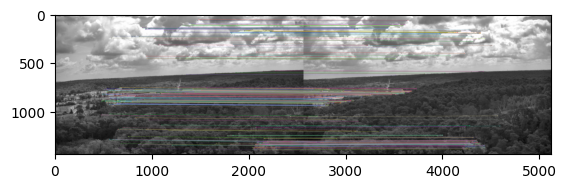

In [3]:
import cv2
import numpy as np
import math
import os # Added for os.path.join

def calculate_rotation_angle_refined(image_path1, image_path2, feature_detector_type="ORB", visualize_matches=False):
    """
    Calculates the rotation angle between two images with refinements.

    Args:
        image_path1 (str): Path to the first image (before rotation).
        image_path2 (str): Path to the second image (after rotation).
        feature_detector_type (str): Type of feature detector ("ORB", "SIFT", "AKAZE").
        visualize_matches (bool): If True, displays the matched features.

    Returns:
        float: Estimated rotation angle in degrees, or None if an error occurs.
    """
    img1 = cv2.imread(image_path1, cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(image_path2, cv2.IMREAD_GRAYSCALE)

    if img1 is None:
        print(f"Error: Could not read image at {image_path1}")
        return None
    if img2 is None:
        print(f"Error: Could not read image at {image_path2}")
        return None

    # 1. Initialize Feature Detector
    # More features can often help.
    if feature_detector_type == "ORB":
        detector = cv2.ORB_create(nfeatures=5000, scoreType=cv2.ORB_FAST_SCORE) # Increased features, try FAST_SCORE
    elif feature_detector_type == "SIFT":
        try:
            detector = cv2.SIFT_create(nfeatures=5000)
        except cv2.error:
            print("SIFT not available or nfeatures not supported in this version. Ensure opencv-contrib-python.")
            print("Falling back to ORB.")
            detector = cv2.ORB_create(nfeatures=5000)
    elif feature_detector_type == "AKAZE":
        # AKAZE is scale-invariant but doesn't have nfeatures parameter in the same way
        detector = cv2.AKAZE_create(threshold=0.001) # Lower threshold might find more features
    else:
        print(f"Unsupported feature detector: {feature_detector_type}. Using ORB.")
        detector = cv2.ORB_create(nfeatures=5000)

    # 2. Find Keypoints and Descriptors
    kp1, des1 = detector.detectAndCompute(img1, None)
    kp2, des2 = detector.detectAndCompute(img2, None)

    if des1 is None or des2 is None:
        print("Error: Could not compute descriptors from one or both images.")
        return None
    if len(kp1) < 10 or len(kp2) < 10: # Increased minimum keypoints
        print(f"Error: Not enough keypoints found. kp1: {len(kp1)}, kp2: {len(kp2)}")
        return None
    print(f"Keypoints found: img1 - {len(kp1)}, img2 - {len(kp2)}")

    # 3. Match Descriptors
    if feature_detector_type in ["ORB", "AKAZE"]: # Binary descriptors
        bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    else: # SIFT (float descriptors)
        bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)

    matches = bf.match(des1, des2)
    matches = sorted(matches, key=lambda x: x.distance)

    # Filter matches based on distance - more aggressive filtering might be needed.
    # Consider Lowe's Ratio Test if not using crossCheck=True, or even with it for SIFT.
    # For crossCheck=True, usually the top N matches are already quite good.
    # Let's try using a percentage, but ensure a minimum number.
    num_good_matches_to_consider = min(len(matches), max(50, int(len(matches) * 0.25))) # Top 25% or at least 50
    good_matches = matches[:num_good_matches_to_consider]

    print(f"Total matches: {len(matches)}, Good matches considered: {len(good_matches)}")

    if len(good_matches) < 10: # Need enough points for robust estimation (e.g., RANSAC needs at least 3 for affine)
        print(f"Error: Not enough good matches after filtering ({len(good_matches)}). Try adjusting matching parameters, image quality, or detector.")
        return None

    if visualize_matches:
        img_matches = cv2.drawMatches(img1, kp1, img2, kp2, good_matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
        plt.imshow(img_matches)

    # 4. Extract location of good matches
    pts1 = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    pts2 = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

    # 5. Estimate Affine Transformation
    # RANSAC threshold is crucial. If your images are high-res, 3-5 pixels might be too loose.
    # If images are lower res or features are very precise, a smaller threshold is better.
    # Let's try a slightly stricter threshold.
    ransac_thresh = 3.0 # Pixels
    # transform_matrix, inliers_mask = cv2.estimateAffinePartial2D(pts1, pts2, method=cv2.RANSAC, ransacReprojThreshold=ransac_thresh)
    
    # Using estimateRigidTransform (now an alias in some versions or part of legacy)
    # estimateAffine2D is more general. For pure rotation (and small translation), estimateAffinePartial2D is good.
    # Let's stick to estimateAffinePartial2D as it's robust.
    transform_matrix, inliers_mask = cv2.estimateAffinePartial2D(
        pts1, pts2,
        method=cv2.RANSAC,
        ransacReprojThreshold=ransac_thresh,
        maxIters=2000,       # Default is 2000
        confidence=0.99      # Default is 0.99
    )


    if transform_matrix is None:
        print(f"Error: Could not estimate transformation. RANSAC failed. Matches: {len(good_matches)}")
        return None

    num_inliers = np.sum(inliers_mask)
    print(f"Number of inliers found by RANSAC: {num_inliers} out of {len(good_matches)} provided matches.")

    if num_inliers < 6: # Need at least 3 pairs for affine, but more for stability
        print(f"Error: RANSAC found too few inliers ({num_inliers}). Transformation is unreliable.")
        return None

    # 6. Extract Rotation Angle from the Affine Matrix
    # M = [[a, -b, tx], [b, a, ty]] where a = s*cos(theta), b = s*sin(theta)
    # angle_rad = math.atan2(transform_matrix[1, 0], transform_matrix[0, 0]) # Standard way

    # Alternative: average angle from skew components to be robust to slight shear
    # angle1 = math.atan2(transform_matrix[1, 0], transform_matrix[0, 0])
    # angle2 = math.atan2(-transform_matrix[0, 1], transform_matrix[1, 1])
    # angle_rad = (angle1 + angle2) / 2.0
    # Check for scale factor:
    # scale_x = np.sqrt(transform_matrix[0,0]**2 + transform_matrix[0,1]**2)
    # scale_y = np.sqrt(transform_matrix[1,0]**2 + transform_matrix[1,1]**2)
    # print(f"Estimated scales: x={scale_x:.3f}, y={scale_y:.3f}")
    # If significant scaling is detected (e.g. > 1.1 or < 0.9) for a pure rotation,
    # it might indicate issues in matching or that the motion isn't purely rotational.

    angle_rad = math.atan2(transform_matrix[1, 0], transform_matrix[0, 0])
    angle_deg = math.degrees(angle_rad)

    # The sign of the angle depends on the coordinate system (OpenCV is y-down).
    # If your ref_150 is rotated counter-clockwise relative to ref_140,
    # and you get a negative angle, it might be correct or might need a sign flip
    # depending on your convention for "positive" rotation.
    # For example, if your PTZ reports positive for CCW rotation.

    return angle_deg

# --- Your Setup ---
base = "/Users/mateo/pyronear/vision/smoke-localization/site_data/nemours/ref_images/192_168_1_11"
image_before_path = os.path.join(base, "ref_140.jpg")
image_after_path  = os.path.join(base, "ref_150.jpg")

# --- Experimentation ---
# 1. Try with ORB and visualize matches first
rotation_orb = calculate_rotation_angle_refined(image_before_path, image_after_path,
                                                feature_detector_type="ORB",
                                                visualize_matches=True) # Set to True
if rotation_orb is not None:
    print(f"Estimated Rotation Angle (ORB): {rotation_orb:.2f} degrees")
else:
    print("Could not calculate rotation angle with ORB.")

print("-" * 30)

# 2. Try with AKAZE (often good)
# rotation_akaze = calculate_rotation_angle_refined(image_before_path, image_after_path,
#                                                   feature_detector_type="AKAZE",
#                                                   visualize_matches=True) # Set to True
# if rotation_akaze is not None:
#     print(f"Estimated Rotation Angle (AKAZE): {rotation_akaze:.2f} degrees")
# else:
#     print("Could not calculate rotation angle with AKAZE.")

# print("-" * 30)

# 3. Try with SIFT (if available and opencv-contrib-python is installed)
# rotation_sift = calculate_rotation_angle_refined(image_before_path, image_after_path,
#                                                  feature_detector_type="SIFT",
#                                                  visualize_matches=True) # Set to True
# if rotation_sift is not None:
#     print(f"Estimated Rotation Angle (SIFT): {rotation_sift:.2f} degrees")
# else:
#     print("Could not calculate rotation angle with SIFT.")

Keypoints found: img1 - 5191, img2 - 5202
Total matches: 2220, Initial 'good' matches for RANSAC: 555
Number of inliers found by RANSAC: 200 out of 555 provided matches.
Estimated Affine Transformation Matrix (M):
[[ 1.03600315e+00  5.73391143e-03 -4.50339693e+02]
 [-5.73391143e-03  1.03600315e+00 -1.31134113e+01]]
Number of matches to draw as inliers: 200
Angle from M[1,0], M[0,0]: -0.3171 degrees
Angle from -M[0,1], M[1,1]: -0.3171 degrees
Scale factor from col0 (sx): 1.0360
Final Estimated Rotation Angle (ORB): -0.32 degrees


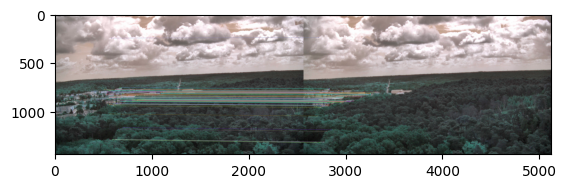

In [2]:
import cv2
import numpy as np
import math
import os
import matplotlib.pyplot as plt 

def calculate_rotation_angle_detailed_debug(image_path1, image_path2, feature_detector_type="ORB", visualize_steps=False):
    """
    Calculates the rotation angle with more detailed debugging output.
    """
    img1_color = cv2.imread(image_path1)
    img2_color = cv2.imread(image_path2)

    if img1_color is None:
        print(f"Error: Could not read image at {image_path1}")
        return None
    if img2_color is None:
        print(f"Error: Could not read image at {image_path2}")
        return None

    img1 = cv2.cvtColor(img1_color, cv2.COLOR_BGR2GRAY)
    img2 = cv2.cvtColor(img2_color, cv2.COLOR_BGR2GRAY)

    if feature_detector_type == "ORB":
        detector = cv2.ORB_create(nfeatures=5000, scoreType=cv2.ORB_FAST_SCORE)
    elif feature_detector_type == "SIFT":
        try:
            detector = cv2.SIFT_create(nfeatures=5000)
        except cv2.error:
            print("SIFT not available. Falling back to ORB.")
            detector = cv2.ORB_create(nfeatures=5000)
    elif feature_detector_type == "AKAZE":
        detector = cv2.AKAZE_create(threshold=0.001)
    else:
        print(f"Unsupported feature detector: {feature_detector_type}. Using ORB.")
        detector = cv2.ORB_create(nfeatures=5000)

    kp1, des1 = detector.detectAndCompute(img1, None)
    kp2, des2 = detector.detectAndCompute(img2, None)

    if des1 is None or des2 is None or len(kp1) < 10 or len(kp2) < 10:
        print(f"Error: Not enough keypoints/descriptors. kp1: {len(kp1)}, kp2: {len(kp2)}")
        return None
    print(f"Keypoints found: img1 - {len(kp1)}, img2 - {len(kp2)}")

    if feature_detector_type in ["ORB", "AKAZE"]:
        bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    else:
        bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)

    matches = bf.match(des1, des2)
    matches = sorted(matches, key=lambda x: x.distance)

    # Filter matches: Use a more conservative number of top matches for RANSAC
    # If sky features have "good" local descriptors, they might pass this initial filter.
    # We might need to be more aggressive or try Lowe's ratio test (see notes below)
    num_initial_good_matches = min(len(matches), max(50, int(len(matches) * 0.25))) # Using your previous value
    # num_initial_good_matches = min(len(matches), 300) # Or try a fixed smaller number of the best
    good_initial_matches = matches[:num_initial_good_matches]

    print(f"Total matches: {len(matches)}, Initial 'good' matches for RANSAC: {len(good_initial_matches)}")

    if len(good_initial_matches) < 10:
        print(f"Error: Not enough initial good matches after filtering ({len(good_initial_matches)}).")
        return None

    if visualize_steps:
        img_initial_matches = cv2.drawMatches(img1_color, kp1, img2_color, kp2, good_initial_matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
        plt.imshow(img_initial_matches)
  

    pts1 = np.float32([kp1[m.queryIdx].pt for m in good_initial_matches]).reshape(-1, 1, 2)
    pts2 = np.float32([kp2[m.trainIdx].pt for m in good_initial_matches]).reshape(-1, 1, 2)

    ransac_thresh = 3.0
    transform_matrix, inliers_mask = cv2.estimateAffinePartial2D(
        pts1, pts2,
        method=cv2.RANSAC,
        ransacReprojThreshold=ransac_thresh,
        maxIters=2000,
        confidence=0.99
    )

    if transform_matrix is None:
        print(f"Error: Could not estimate transformation. RANSAC failed. Initial matches provided: {len(good_initial_matches)}")
        return None

    num_inliers = np.sum(inliers_mask)
    print(f"Number of inliers found by RANSAC: {num_inliers} out of {len(good_initial_matches)} provided matches.")
    print("Estimated Affine Transformation Matrix (M):")
    print(transform_matrix)

    if num_inliers < 10: # Increased minimum for more stability
        print(f"Error: RANSAC found too few inliers ({num_inliers}). Transformation is unreliable.")
        return None

    # Visualize only INLIER matches
    if visualize_steps and inliers_mask is not None:
        inlier_matches = [m for i, m in enumerate(good_initial_matches) if inliers_mask[i,0] == 1]
        print(f"Number of matches to draw as inliers: {len(inlier_matches)}")
        img_inlier_matches = cv2.drawMatches(img1_color, kp1, img2_color, kp2, inlier_matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
        plt.imshow(img_inlier_matches)



    # Extract Rotation Angle
    # M = [[a, -b, tx],
    #      [b,  a, ty]]
    # a = s*cos(theta), b = s*sin(theta)
    # scale_s = sqrt(M[0,0]**2 + M[1,0]**2) or sqrt(M[0,1]**2 + M[1,1]**2)
    # cos_theta = M[0,0] / scale_s
    # sin_theta = M[1,0] / scale_s
    # theta_from_col0 = math.atan2(M[1,0], M[0,0]) # sin_theta / cos_theta
    # theta_from_col1 = math.atan2(-M[0,1], M[1,1]) # sin_theta_prime / cos_theta_prime from second column

    # Robust way to get angle and scale
    sx = np.sqrt(transform_matrix[0,0]**2 + transform_matrix[1,0]**2) # Scale factor from first column
    #sy = np.sqrt(transform_matrix[0,1]**2 + transform_matrix[1,1]**2) # Scale factor from second column (should be similar)

    # Assuming sx is the scale 's'
    # M[0,0] = s * cos(theta)  => cos(theta) = M[0,0] / s
    # M[1,0] = s * sin(theta)  => sin(theta) = M[1,0] / s
    # M[0,1] = -s * sin(theta) => sin(theta) = -M[0,1] / s
    # M[1,1] = s * cos(theta)  => cos(theta) = M[1,1] / s

    angle_rad_col0 = math.atan2(transform_matrix[1,0], transform_matrix[0,0])
    angle_rad_col1 = math.atan2(-transform_matrix[0,1], transform_matrix[1,1]) # Note the negation for -b component

    angle_deg_col0 = math.degrees(angle_rad_col0)
    angle_deg_col1 = math.degrees(angle_rad_col1)

    print(f"Angle from M[1,0], M[0,0]: {angle_deg_col0:.4f} degrees")
    print(f"Angle from -M[0,1], M[1,1]: {angle_deg_col1:.4f} degrees")
    print(f"Scale factor from col0 (sx): {sx:.4f}")
    #print(f"Scale factor from col1 (sy): {sy:.4f}")


    # If angles from both methods differ significantly, it indicates shear/non-uniform scaling,
    # and the affine model might not be a pure rotation + uniform scale + translation.
    # For pure rotation, these should be very close.
    final_angle_deg = angle_deg_col0 # Choose one, or average if very close

    if abs(angle_deg_col0 - angle_deg_col1) > 1.0: # If angles differ by more than 1 degree
        print("Warning: Significant difference between angles from matrix columns. Model may include shear.")
        # You might choose to average them or flag as unreliable.
        # final_angle_deg = (angle_deg_col0 + angle_deg_col1) / 2.0

    if sx < 0.9 or sx > 1.1: # Check if scale is far from 1
        print(f"Warning: Scale factor ({sx:.3f}) is not close to 1.0. Motion may not be purely rigid.")

    if visualize_steps:
        cv2.destroyAllWindows()

    return final_angle_deg

# --- Your Setup ---
base = "/Users/mateo/pyronear/vision/smoke-localization/site_data/nemours/ref_images/192_168_1_11"
image_before_path = os.path.join(base, "ref_140.jpg")
image_after_path  = os.path.join(base, "ref_150.jpg")

# --- Run with detailed debugging ---
# Set visualize_steps to True to see the images
rotation = calculate_rotation_angle_detailed_debug(image_before_path, image_after_path,
                                                   feature_detector_type="ORB",
                                                   visualize_steps=True)

if rotation is not None:
    print(f"Final Estimated Rotation Angle (ORB): {rotation:.2f} degrees")
else:
    print("Could not calculate rotation angle with ORB.")

In [3]:
import cv2
import numpy as np
import math

def calculate_camera_yaw(image_path1,
                         image_path2,
                         K,               # 3×3 camera intrinsic matrix
                         feature_detector="ORB",
                         visualize=False):
    """
    Returns the yaw angle (in degrees) by estimating the 3D rotation around the camera's vertical axis.
    K must be your calibrated intrinsics (fx, fy, cx, cy).
    """
    # 1. load and grayscale
    I1 = cv2.imread(image_path1)
    I2 = cv2.imread(image_path2)
    gray1 = cv2.cvtColor(I1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(I2, cv2.COLOR_BGR2GRAY)
    
    # 2. feature detection
    if feature_detector == "SIFT":
        detector = cv2.SIFT_create(nfeatures=5000)
    else:
        detector = cv2.ORB_create(nfeatures=5000)
    
    kp1, des1 = detector.detectAndCompute(gray1, None)
    kp2, des2 = detector.detectAndCompute(gray2, None)
    
    # 3. matching with ratio test
    if feature_detector == "SIFT":
        bf = cv2.BFMatcher(cv2.NORM_L2)
    else:
        bf = cv2.BFMatcher(cv2.NORM_HAMMING)
    
    raw_matches = bf.knnMatch(des1, des2, k=2)
    good = [m for m,n in raw_matches if m.distance < 0.75 * n.distance]
    if len(good) < 20:
        raise RuntimeError(f"Too few good matches: {len(good)}")
    
    pts1 = np.float32([ kp1[m.queryIdx].pt for m in good ]).reshape(-1,1,2)
    pts2 = np.float32([ kp2[m.trainIdx].pt for m in good ]).reshape(-1,1,2)
    
    # 4. Essential matrix and R|t
    E, mask = cv2.findEssentialMat(
        pts1, pts2,
        K,
        method=cv2.RANSAC,
        prob=0.999,
        threshold=1.0
    )
    if E is None:
        raise RuntimeError("Essential matrix estimation failed")
    
    _, R, t, mask_pose = cv2.recoverPose(E, pts1, pts2, K)
    
    # 5. extract yaw from R (rotation about camera y axis)
    # R ≈ R_y(yaw) for pure pan, where R[0,2] = sin(yaw), R[2,2] = cos(yaw)
    yaw_rad = math.atan2(R[0,2], R[2,2])
    yaw_deg = math.degrees(yaw_rad)
    
    if visualize:
        inliers1 = pts1[mask_pose.ravel()==1]
        inliers2 = pts2[mask_pose.ravel()==1]
        img_vis = cv2.hconcat([
            cv2.drawKeypoints(I1, [kp1[m.queryIdx] for i,m in enumerate(good) if mask_pose[i]], None),
            cv2.drawKeypoints(I2, [kp2[m.trainIdx] for i,m in enumerate(good) if mask_pose[i]], None)
        ])
        cv2.imshow("Inlier Features", img_vis)
        cv2.waitKey(0)
        cv2.destroyAllWindows()
    
    return yaw_deg

# example usage:
K = np.array([[fx,  0, cx],
              [ 0, fy, cy],
              [ 0,  0,  1]], dtype=float)

image_before_path = os.path.join(base, "ref_140.jpg")
image_after_path  = os.path.join(base, "ref_150.jpg")

yaw = calculate_camera_yaw(
    image_before_path,
    image_after_path,
    K,
    feature_detector="ORB",
    visualize=True
)
print(f"Estimated camera yaw: {yaw:.2f}°")


NameError: name 'fx' is not defined

In [5]:
import cv2
import numpy as np
import math

def filter_and_compute_kp_des(gray, detector, keep_top_ratio=0.8):
    """
    Detect keypoints in gray image but ignore the bottom (1 - keep_top_ratio) fraction.
    Returns filtered keypoints and descriptors.
    """
    h, w = gray.shape
    # build a mask that is white on the top region and black on the bottom
    mask = np.zeros((h, w), dtype=np.uint8)
    mask[: int(h * keep_top_ratio), :] = 255

    kp, des = detector.detectAndCompute(gray, mask)
    return kp, des

def estimate_pan_with_mask(
    img_path1, img_path2, keep_top_ratio=0.8, feature_type="ORB"
):
    I1 = cv2.imread(img_path1)
    I2 = cv2.imread(img_path2)
    gray1 = cv2.cvtColor(I1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(I2, cv2.COLOR_BGR2GRAY)

    # create ORB or SIFT
    if feature_type == "SIFT":
        detector = cv2.SIFT_create(nfeatures=5000)
        norm = cv2.NORM_L2
    else:
        detector = cv2.ORB_create(nfeatures=5000)
        norm = cv2.NORM_HAMMING

    # detect only in the top region
    kp1, des1 = filter_and_compute_kp_des(gray1, detector, keep_top_ratio)
    kp2, des2 = filter_and_compute_kp_des(gray2, detector, keep_top_ratio)

    # match with ratio test
    bf = cv2.BFMatcher(norm)
    raw = bf.knnMatch(des1, des2, k=2)
    good = [m for m,n in raw if m.distance < 0.75 * n.distance]

    pts1 = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1,1,2)
    pts2 = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1,1,2)

    # estimate homography as before
    H, _ = cv2.findHomography(pts1, pts2, method=cv2.RANSAC, ransacReprojThreshold=3.0)
    if H is None:
        raise RuntimeError("Homography failed")

    # force det=1
    H = H / np.cbrt(np.linalg.det(H))
    U, S, Vt = np.linalg.svd(H)
    M = np.diag([1, 1, np.linalg.det(U @ Vt)])
    R = U @ M @ Vt

    # yaw from R
    yaw = math.degrees(math.atan2(R[0,2], R[2,2]))
    return yaw

# usage
pan_deg = estimate_pan_with_mask(
    image_before_path,
    image_after_path,
    keep_top_ratio=0.9,   # ignore bottom 20% of the frame
    feature_type="ORB"
)
print(f"Estimated pan after masking near objects: {pan_deg:.2f}°")


Estimated pan after masking near objects: -89.75°


Image size: width=2560, height=1440
Using top 80.0% of image, mask shape: (1440, 2560)
Detected keypoints: img1=5000, img2=4925
Raw matches: 5000, Good matches: 1216
Raw homography H:
 [[ 1.09115507e+00  7.73186194e-03 -4.80853903e+02]
 [ 2.24558956e-02  1.06219773e+00 -2.65492132e+01]
 [ 3.59494010e-05  9.33060464e-06  1.00000000e+00]]
Determinant of H before normalization: 1.1774e+00
Normalized H (det=1):
 [[ 1.03335252e+00  7.32227643e-03 -4.55381282e+02]
 [ 2.12663232e-02  1.00592916e+00 -2.51428025e+01]
 [ 3.40450274e-05  8.83632778e-06  9.47026277e-01]]
Singular values S: [4.56077011e+02 1.00463143e+00 2.18250405e-03]
Projected rotation R:
 [[ 0.00629762 -0.05488251 -0.99847296]
 [-0.03533645  0.99785693 -0.05507153]
 [ 0.99935563  0.03562931  0.00434477]]
Inliers: 968 / 1216 good matches
Estimated yaw (pan): -89.75°


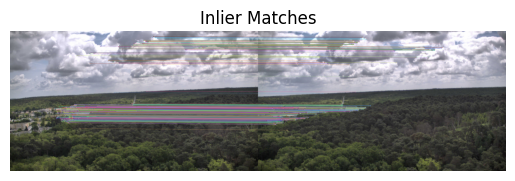

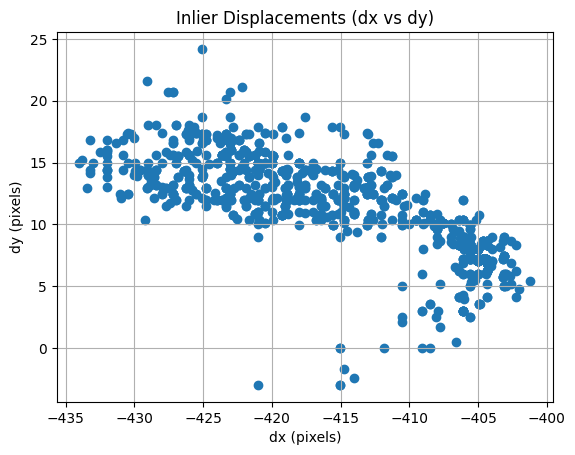

Final Estimated Pan: -89.75°


In [6]:
import cv2
import numpy as np
import math
import matplotlib.pyplot as plt

def estimate_pan_with_debug(
    img_path1, img_path2,
    keep_top_ratio=0.8,
    feature_type="ORB"
):
    # 1. Load images and convert to grayscale
    I1 = cv2.imread(img_path1)
    I2 = cv2.imread(img_path2)
    gray1 = cv2.cvtColor(I1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(I2, cv2.COLOR_BGR2GRAY)
    h, w = gray1.shape
    print(f"Image size: width={w}, height={h}")

    # 2. Build mask to ignore bottom of frame
    mask = np.zeros_like(gray1, dtype=np.uint8)
    mask[:int(h * keep_top_ratio), :] = 255
    print(f"Using top {keep_top_ratio*100:.1f}% of image, mask shape: {mask.shape}")

    # 3. Create feature detector
    if feature_type == "SIFT":
        detector = cv2.SIFT_create(nfeatures=5000)
        norm = cv2.NORM_L2
    else:
        detector = cv2.ORB_create(nfeatures=5000)
        norm = cv2.NORM_HAMMING

    # 4. Detect and compute with mask
    kp1, des1 = detector.detectAndCompute(gray1, mask)
    kp2, des2 = detector.detectAndCompute(gray2, mask)
    print(f"Detected keypoints: img1={len(kp1)}, img2={len(kp2)}")

    # 5. Match with ratio test
    bf = cv2.BFMatcher(norm)
    raw_matches = bf.knnMatch(des1, des2, k=2)
    good_matches = [m for m, n in raw_matches if m.distance < 0.75 * n.distance]
    print(f"Raw matches: {len(raw_matches)}, Good matches: {len(good_matches)}")

    # 6. Prepare matched points
    pts1 = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    pts2 = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

    # 7. Estimate homography with RANSAC
    H, maskH = cv2.findHomography(pts1, pts2, method=cv2.RANSAC, ransacReprojThreshold=3.0)
    if H is None:
        print("Error: Homography estimation failed")
        return None
    print("Raw homography H:\n", H)

    # 8. Normalize H to det=1
    detH = np.linalg.det(H)
    print(f"Determinant of H before normalization: {detH:.4e}")
    H /= np.cbrt(detH)
    print("Normalized H (det=1):\n", H)

    # 9. Project onto SO(3)
    U, S, Vt = np.linalg.svd(H)
    print("Singular values S:", S)
    M = np.diag([1, 1, np.linalg.det(U @ Vt)])
    R = U @ M @ Vt
    print("Projected rotation R:\n", R)

    # 10. Extract yaw
    yaw_rad = math.atan2(R[0, 2], R[2, 2])
    yaw_deg = math.degrees(yaw_rad)

    inliers = maskH.ravel() == 1
    print(f"Inliers: {np.sum(inliers)} / {len(good_matches)} good matches")
    print(f"Estimated yaw (pan): {yaw_deg:.2f}°")

    # 11. Plot inlier matches
    inlier_matches = [m for i, m in enumerate(good_matches) if inliers[i]]
    match_vis = cv2.drawMatches(
        I1, kp1, I2, kp2, inlier_matches, None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )
    match_vis_rgb = cv2.cvtColor(match_vis, cv2.COLOR_BGR2RGB)
    plt.figure()
    plt.imshow(match_vis_rgb)
    plt.title("Inlier Matches")
    plt.axis("off")

    # 12. Plot displacement scatter (dx vs dy)
    pts1_in = np.array([kp1[m.queryIdx].pt for i, m in enumerate(good_matches) if inliers[i]])
    pts2_in = np.array([kp2[m.trainIdx].pt for i, m in enumerate(good_matches) if inliers[i]])
    dx = pts2_in[:, 0] - pts1_in[:, 0]
    dy = pts2_in[:, 1] - pts1_in[:, 1]

    plt.figure()
    plt.scatter(dx, dy)
    plt.title("Inlier Displacements (dx vs dy)")
    plt.xlabel("dx (pixels)")
    plt.ylabel("dy (pixels)")
    plt.grid(True)
    plt.show()

    return yaw_deg

# Example usage (replace with your paths):
yaw = estimate_pan_with_debug(
    "/Users/mateo/pyronear/vision/smoke-localization/site_data/nemours/ref_images/192_168_1_11/ref_140.jpg",
    "/Users/mateo/pyronear/vision/smoke-localization/site_data/nemours/ref_images/192_168_1_11/ref_150.jpg",
    keep_top_ratio=0.8,
    feature_type="ORB"
)
print(f"Final Estimated Pan: {yaw:.2f}°")


Image size: 2560×1440
Approx K:
 [[2.50133932e+03 0.00000000e+00 1.28000000e+03]
 [0.00000000e+00 2.50133932e+03 7.20000000e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
Keypoints detected: img1=5000, img2=5000
Raw matches: 5000, After ratio test: 1331
Essential matrix E:
 [[-0.00323525 -0.02686586 -0.04102868]
 [-0.03078745 -0.00123868 -0.70523226]
 [ 0.03783418  0.70557153 -0.00445614]]
recoverPose inliers: 1076 / 1331
Recovered rotation R:
 [[ 0.99666335  0.00444516 -0.08150094]
 [-0.00458724  0.99998827 -0.00155613]
 [ 0.08149307  0.0019248   0.99667205]]
Estimated yaw (pan): -4.67°


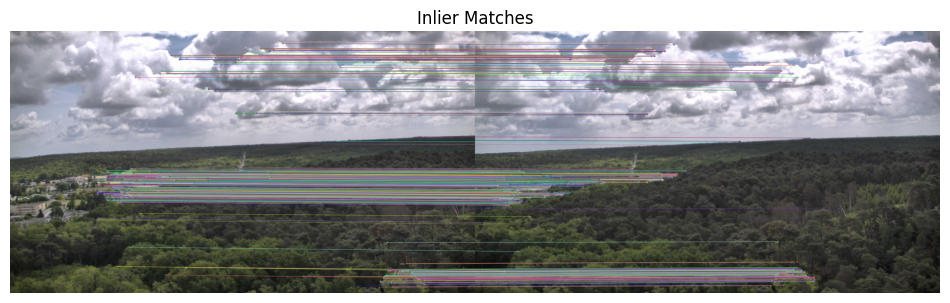

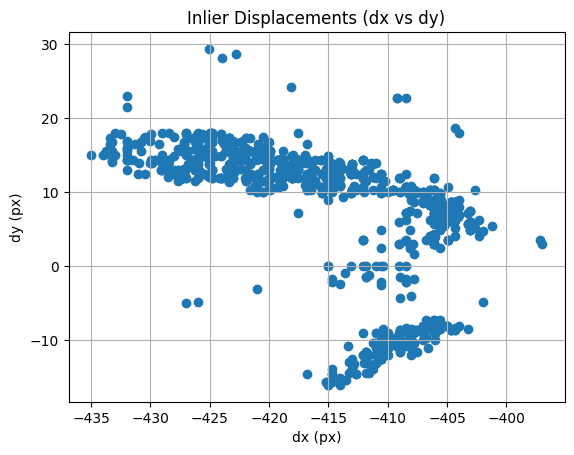

Final estimate: -4.6748506361939555


In [7]:
import cv2
import numpy as np
import math
import matplotlib.pyplot as plt

def estimate_pan_with_fov_debug(
    img_path1,
    img_path2,
    fov_deg,            # horizontal field of view in degrees
    feature_type="ORB",
    ratio_thresh=0.75,
    ransac_thresh=1.0
):
    # 1) load + gray
    I1 = cv2.imread(img_path1)
    I2 = cv2.imread(img_path2)
    if I1 is None or I2 is None:
        raise FileNotFoundError("Check your image paths")
    h, w = I1.shape[:2]
    gray1 = cv2.cvtColor(I1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(I2, cv2.COLOR_BGR2GRAY)
    print(f"Image size: {w}×{h}")

    # 2) approximate intrinsics K from horizontal FOV
    #    f = (w/2) / tan(FOV/2)
    f = (w * 0.5) / math.tan(math.radians(fov_deg * 0.5))
    cx, cy = w * 0.5, h * 0.5
    K = np.array([[f, 0, cx],
                  [0, f, cy],
                  [0, 0,  1]], dtype=np.float64)
    print("Approx K:\n", K)

    # 3) detect & describe
    if feature_type.upper() == "SIFT":
        detector = cv2.SIFT_create(nfeatures=5000)
        norm = cv2.NORM_L2
    else:
        detector = cv2.ORB_create(nfeatures=5000)
        norm = cv2.NORM_HAMMING

    kp1, des1 = detector.detectAndCompute(gray1, None)
    kp2, des2 = detector.detectAndCompute(gray2, None)
    print(f"Keypoints detected: img1={len(kp1)}, img2={len(kp2)}")

    # 4) knn-match + ratio test
    bf = cv2.BFMatcher(norm)
    raw = bf.knnMatch(des1, des2, k=2)
    good = [m for m,n in raw if m.distance < ratio_thresh * n.distance]
    print(f"Raw matches: {len(raw)}, After ratio test: {len(good)}")
    if len(good) < 20:
        raise RuntimeError("Too few good matches")

    pts1 = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1,1,2)
    pts2 = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1,1,2)

    # 5) Essential matrix + RANSAC
    E, maskE = cv2.findEssentialMat(
        pts1, pts2, K,
        method=cv2.RANSAC,
        prob=0.999,
        threshold=ransac_thresh
    )
    if E is None:
        raise RuntimeError("Essential matrix failed")
    print("Essential matrix E:\n", E)

    # 6) recoverPose → R, t
    _, R, t, mask_pose = cv2.recoverPose(E, pts1, pts2, K, mask=maskE)
    inliers = mask_pose.ravel().sum()
    print(f"recoverPose inliers: {inliers} / {len(good)}")

    # 7) debug print of R
    print("Recovered rotation R:\n", R)

    # 8) yaw = rotation about camera Y: 
    #    for a pure pan R[0,2]=sin(yaw), R[2,2]=cos(yaw)
    yaw = math.degrees(math.atan2(R[0,2], R[2,2]))
    print(f"Estimated yaw (pan): {yaw:.2f}°")

    # 9) visualize inlier matches
    inlier_matches = [m for i,m in enumerate(good) if mask_pose[i]]
    vis = cv2.drawMatches(
        I1, kp1, I2, kp2, inlier_matches, None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )
    vis = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12,5))
    plt.imshow(vis)
    plt.title("Inlier Matches")
    plt.axis("off")

    # 10) scatter dx,dy of inliers
    pts1i = np.array([kp1[m.queryIdx].pt for i,m in enumerate(good) if mask_pose[i]])
    pts2i = np.array([kp2[m.trainIdx].pt for i,m in enumerate(good) if mask_pose[i]])
    dx = pts2i[:,0] - pts1i[:,0]
    dy = pts2i[:,1] - pts1i[:,1]
    plt.figure()
    plt.scatter(dx, dy)
    plt.title("Inlier Displacements (dx vs dy)")
    plt.xlabel("dx (px)")
    plt.ylabel("dy (px)")
    plt.grid(True)
    plt.show()

    return yaw

# --- Usage ---
yaw = estimate_pan_with_fov_debug(
    "/Users/mateo/pyronear/vision/smoke-localization/site_data/nemours/ref_images/192_168_1_11/ref_140.jpg",
    "/Users/mateo/pyronear/vision/smoke-localization/site_data/nemours/ref_images/192_168_1_11/ref_150.jpg",
    fov_deg=54.2,
    feature_type="ORB"
)
print("Final estimate:", yaw)
